    -- Como primer paso importaremos las librerías, herramientas, modelos y demás que usaremos durante este ejercicio/proyecto

In [959]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

    --Tenemos dos dataframes diferentes con información referente a observaciones compartidas, debemos cruzarlos

In [960]:
df_1 = pd.read_csv('C:/Users/Yoog/Documents/Adrián Fdez López/Carrera/Curso Data Scientist/Credit_card.csv')
df_2 = pd.read_csv('C:/Users/Yoog/Documents/Adrián Fdez López/Carrera/Curso Data Scientist/Credit_card_label.csv')

df = df_1.merge(df_2, on = 'Ind_ID')
df

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,1,0,0,0,Managers,2,0
1544,5023655,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,1,0,0,0,Accountants,1,0
1545,5115992,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,1,0,0,0,Managers,4,0
1546,5118219,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,1,1,1,0,Drivers,2,0


In [961]:
df.shape

(1548, 19)

In [962]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   str    
 2   Car_Owner        1548 non-null   str    
 3   Propert_Owner    1548 non-null   str    
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   str    
 7   EDUCATION        1548 non-null   str    
 8   Marital_status   1548 non-null   str    
 9   Housing_type     1548 non-null   str    
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   str    
 17  Family_Members   1548 non

    --Con estas dos comprobaciones rápidas obtenemos las dimensiones del dataframe final y además observamos de un primer vistazo la existencia (o no) de nulos en nuestras variables

In [963]:
df.isnull().sum()
#De esta manera detectamos cuales son realmente las variables con nulos

Ind_ID               0
GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Mobile_phone         0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

Observamos que hay variables que no dan ningún poder predictivo como 'Ind_ID' o 'Mobile_phone' por lo que pasamos a eliminar el ruido del modelo

In [964]:
df = df.drop(columns = ['Ind_ID', 'Mobile_phone'])
df.shape

(1548, 17)

In [965]:
print(f"Mínimo valor 'GENDER': {df['GENDER'].min()}")
print(f"Mínimo valor 'Annual_income': {df['Annual_income'].min()}")
print(f"Mínimo valor 'Birthday_count': {df['Birthday_count'].min()}")
print(f"Mínimo valor 'Type_Occupation': {df['Type_Occupation'].min()}")  

Mínimo valor 'GENDER': F
Mínimo valor 'Annual_income': 33750.0
Mínimo valor 'Birthday_count': -24946.0
Mínimo valor 'Type_Occupation': Accountants


De esta manera comprobamos cuales son los valores mínimos en las diferentes variables que presentan nulos. Entendiendo que:

    -Na en 'GENDER' puede significar que no se quiere especificar.
    -Na en 'Annual_Income' puede significar que esté desempleado.
    -Na en 'Birthday_Count' en principio sería un error porque no puede significar un cero ya que sería alguien recién nacido.
    -Na en 'Type_Occupation' podría significar alguien desempleado. Es una evidente señal de riesgo y alarma ante impagos. 

In [966]:
numeric_cols = df.select_dtypes(include = [np.number]).columns.tolist()
categoric_cols = df.select_dtypes(exclude = [np.number]).columns.tolist()
print(numeric_cols)
print(categoric_cols)

['CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Family_Members', 'label']
['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']


## Tratado de Nulos en Variables Categóricas

In [967]:
df[categoric_cols].isnull().sum()

GENDER               7
Car_Owner            0
Propert_Owner        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Type_Occupation    488
dtype: int64

Entendemos que en una variable categórica demográfica como es el género cuando se presenta un pequeño número de nulos esto indica error, simplemente rellenaremos con la moda del df.

In [968]:
moda_genero = df['GENDER'].mode()[0]
df['GENDER'] = df['GENDER'].fillna(moda_genero)
df['GENDER'].isnull().sum()

np.int64(0)

In [969]:
df['Type_Occupation'].value_counts()

Type_Occupation
Laborers                 268
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

In [970]:
df[(df['Type_Occupation'].isnull()) & (df['Employed_days'] > 0)]

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,0,0,0,NaN,2,1
7,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22134.0,365243,0,0,0,NaN,2,1
26,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,0,1,0,NaN,2,1
27,F,N,Y,0,NaN,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,0,1,0,NaN,2,1
31,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21876.0,365243,0,1,1,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509,F,Y,Y,0,157500.0,Pensioner,Secondary / secondary special,Widow,House / apartment,-20432.0,365243,0,0,0,NaN,1,0
1511,F,N,Y,0,216000.0,Pensioner,Higher education,Single / not married,House / apartment,-20388.0,365243,0,0,0,NaN,1,0
1514,F,N,N,0,69750.0,Pensioner,Secondary / secondary special,Widow,Municipal apartment,-21986.0,365243,0,1,0,NaN,1,0
1525,F,Y,Y,0,175500.0,Pensioner,Higher education,Married,House / apartment,-22077.0,365243,0,1,0,NaN,2,0


Sabemos que cuando 'Employed_days' > 0 esto significa que hablamos de alguien desempleado por lo que podemos rellenar a estas personas como desempleadas.

In [971]:
df.loc[df[(df['Type_Occupation'].isnull()) & (df['Employed_days'] > 0)].index, 'Type_Occupation'] = "Unemployed"
df['Type_Occupation'].value_counts()

Type_Occupation
Laborers                 268
Unemployed               261
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

In [972]:
df[categoric_cols].isnull().sum()

GENDER               0
Car_Owner            0
Propert_Owner        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Type_Occupation    227
dtype: int64

Hemos solucionado los nulos en las variables categóricas por lo que ahora podemos apoyarnos en ellas hacer la imputación numérica

## Tratado de Nulos en Variables Numéricas

In [973]:
df[numeric_cols].isnull().sum()

CHILDREN           0
Annual_income     23
Birthday_count    22
Employed_days      0
Work_Phone         0
Phone              0
EMAIL_ID           0
Family_Members     0
label              0
dtype: int64

In [974]:
df[df['Annual_income']==0]

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label


Observamos que no hay datos para personas con 'Annual_income' igual a cero entonces no vamos a imputar los nulos como cero pues serían valores atípicos. 

Hagamos un análisis para ver con que valor imputaremos estos nulos

Text(0.5, 1.0, 'Annual_income')

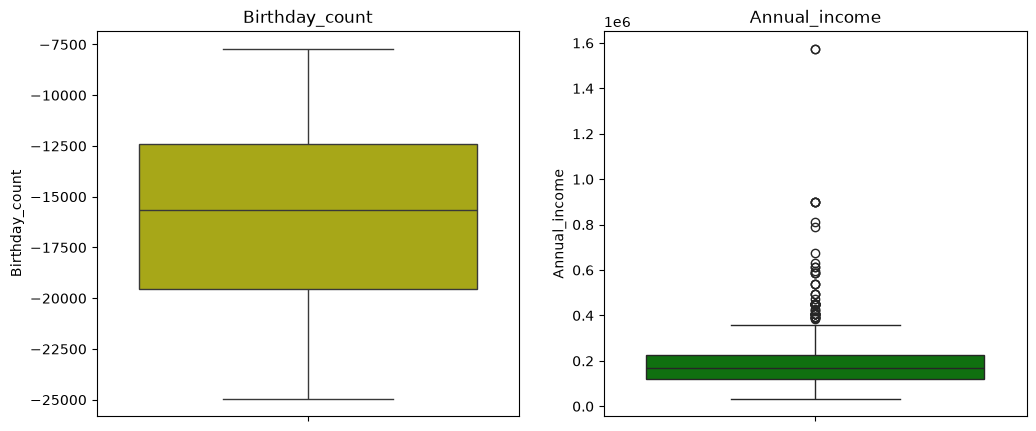

In [975]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data = df['Birthday_count'], color = 'y')
plt.title('Birthday_count')
plt.subplot(1, 2, 2)
sns.boxplot(data = df['Annual_income'], color = 'g')
plt.title('Annual_income')

Observando que, las dos columnas numéricas que presentan nulos son el ingreso anual y la edad de los clientes podríamos pensar que es más óptimo rellenar los nulos en estas variables con la media/mediana de nuestros datos antes que con ceros pues tendrían poco sentido. 

    Puesto que sabemos que la mediana es más resistente frente a outliers o valores extremos utilizaremos este valor para rellenar nulos.

Antes vamos a seleccionar que variables tienen más correlación con las que vamos a rellenar para calcular la mediana específica de cada nulo con relación a su variable más representativa y explicativa

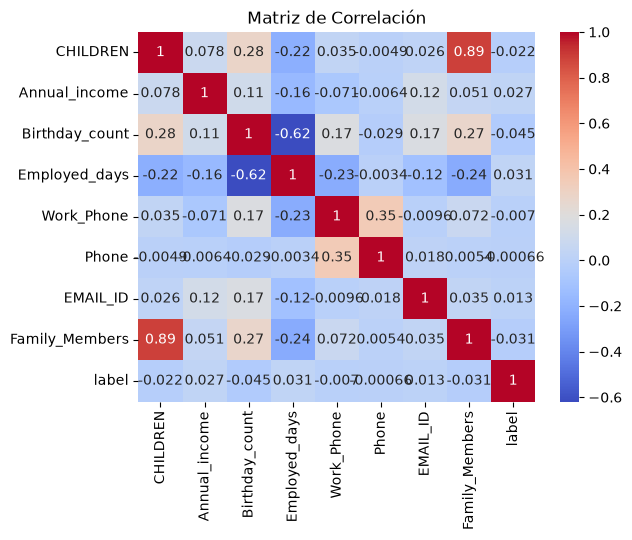

In [976]:
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = 'coolwarm')
#sns.heatmap(df_eda.drop('Sucursal', axis = 1).corr(), annot = True, cmap = 'coolwarm')
#Podríamos hacerlo eliminando la columna que sabemos que es de texto 
#o simplemente si no conocemos el df al completo decirle que se fije únicamente en las columnas numéricas
plt.title('Matriz de Correlación')
plt.show()

Sacamos poca información del 'heatmap' pues muestra correlaciones de Ingresos Anuales con el Email Id, o de la Edad con el número de hijos/miembros de la familia que son, en realidad poco representativos.

Como regla de negocio entendemos que la mayor correlación con los ingresos las tendrán variables como el tipo de puesto o los estudios por lo que vamos a comprobar si hay saltos en los diferentes niveles de las variables y a imputar por ellas.

In [977]:
# Comprobamos cómo varía el sueldo según el puesto
df.groupby('Type_Occupation')['Annual_income'].median().sort_values()

Type_Occupation
Waiters/barmen staff      94500.0
IT staff                 103500.0
Security staff           112500.0
Cooking staff            112500.0
Cleaning staff           132750.0
Unemployed               135000.0
Secretaries              135000.0
Low-skill Laborers       135000.0
HR staff                 144000.0
Sales staff              157500.0
Core staff               157500.0
Private service staff    157500.0
Medicine staff           157500.0
Laborers                 166500.0
High skill tech staff    180000.0
Accountants              180000.0
Realty agents            202500.0
Drivers                  225000.0
Managers                 225000.0
Name: Annual_income, dtype: float64

In [978]:
# Comprobamos cómo varía el sueldo según el nivel educativo
df.groupby('EDUCATION')['Annual_income'].median().sort_values()

EDUCATION
Lower secondary                  135000.0
Secondary / secondary special    157500.0
Incomplete higher                180000.0
Higher education                 202500.0
Academic degree                  236250.0
Name: Annual_income, dtype: float64

Observamos que ambas tienen bastante poder predictivo por lo que podríamos hacer una imputación en cascada para rellenar si hubiera nulos en ambas variables pero ya no las hay por lo que simplemente usamos la media para rellenar estas variables

In [979]:
#Imputación Principal por Ocupación
df['Annual_income'] = df['Annual_income'].fillna(
    df.groupby('Type_Occupation')['Annual_income'].transform('median')
)
df['Birthday_count'] = df['Birthday_count'].fillna(
    df.groupby('Type_Occupation')['Birthday_count'].transform('median'))

#Red de seguridad final (Mediana global por si acaso)
df['Annual_income'] = df['Annual_income'].fillna(df['Annual_income'].median())
df['Birthday_count'] = df['Birthday_count'].fillna(df['Birthday_count'].median())


#Comprobación de que no quedan nulos en la columna
print("Nulos restante en 'Annual_income':", df['Annual_income'].isnull().sum())
print("Nulos restante en 'Birthday_count':", df['Birthday_count'].isnull().sum())


Nulos restante en 'Annual_income': 0
Nulos restante en 'Birthday_count': 0


In [980]:
df.isnull().sum()


GENDER               0
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count       0
Employed_days        0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    227
Family_Members       0
label                0
dtype: int64

In [981]:
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,0,0,0,Unemployed,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-15621.0,-586,1,1,0,NaN,2,1
3,F,Y,N,0,163800.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1


## Análisis Exploratorio

Observamos un error pues las variables ``Phone`` , ``Work_Phone`` e ``EMAIL_ID`` son tratadas coomo numéricas cuando realmente hablamos de 'tener' o no, entonces usemos replace para transformarlas.

In [982]:
# Convertir 1 en 'Si' y 0 en 'No' en las variables binarias
df[['Work_Phone', 'Phone', 'EMAIL_ID']] = df[['Work_Phone', 'Phone', 'EMAIL_ID']].replace({1: 'Si', 0: 'No'})

# Check
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,No,No,No,Unemployed,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,Si,Si,No,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-15621.0,-586,Si,Si,No,NaN,2,1
3,F,Y,N,0,163800.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,Si,Si,No,NaN,2,1
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,Si,Si,No,NaN,2,1


In [983]:
numeric_cols = df.select_dtypes(include = [np.number]).columns.tolist()
categoric_cols = df.select_dtypes(exclude = [np.number]).columns.tolist()
print("Numéricas:", numeric_cols)
print("Categóricas:", categoric_cols)

Numéricas: ['CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Family_Members', 'label']
Categóricas: ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation']


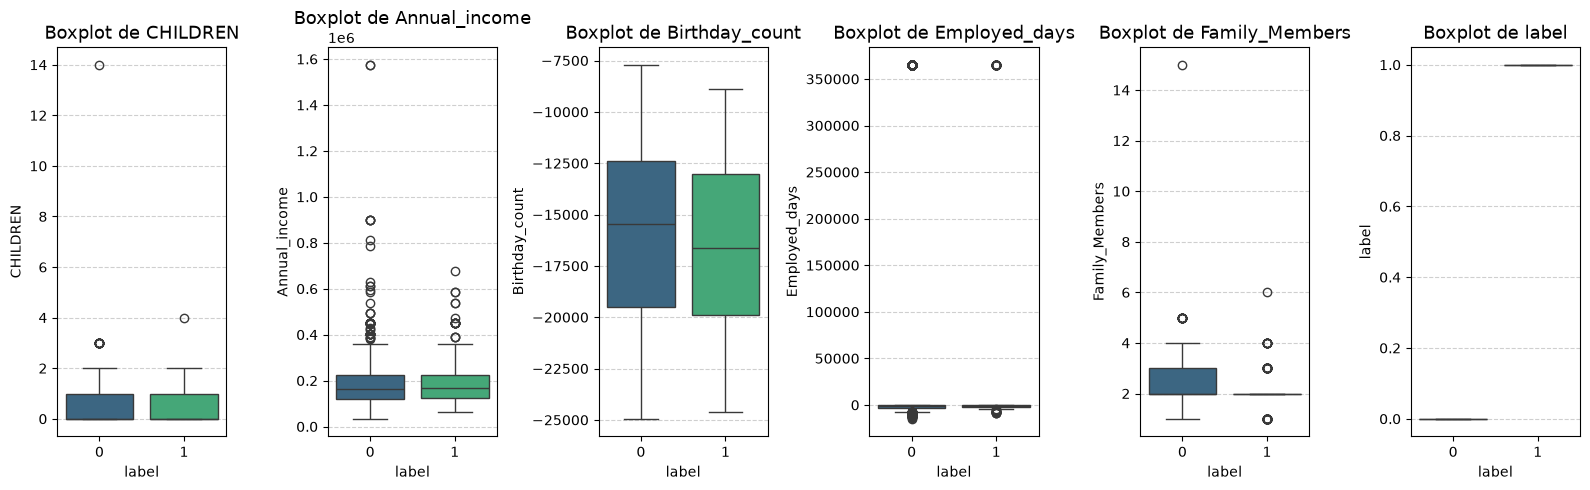

In [984]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración de la figura(creamos una cuadrícula de subplots)
fig, axes = plt.subplots(nrows = 1, ncols = 6, figsize = (16, 5))    
#Llama a los subplots indicando que tiene 2 filas y 5 columnas
#Llama a fig y axes de esta manera e itera sobre ellos, los subplots
axes = axes.flatten() #Hacemos que la matriz se transforme en unidimensional
#para no tener que hacer bucles con dos coordenadas

#Iteración para pintar cada subplot
for i, col in enumerate(numeric_cols):    #'enumerate' al pasarle una lista genera un contador numéritco
    sns.boxplot(                      #entonces 'i' valdría 0,1,2... y 'col' valdría 'edad,ingreso...'
        data = df,                    #con 'i' indicas a seaborn en que subplot estás y con 'col' extraes los datos del df
        x = 'label',
        y = col, 
        ax = axes[i],         #Que subplot estoy considerando
        hue = 'label',
        palette = 'viridis',
        orient = 'v',
        legend = False,       #Quita la leyenda repetitiva
    )
    axes[i].set_title(f"Boxplot de {col}", fontsize = 13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis = 'y', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

Recortamos las familias a miembros de MÁXIMO 8 miembros como es algo lógico

In [985]:
df['CHILDREN'] = df['CHILDREN'].clip(upper = 6)
df['Family_Members'] = df['Family_Members'].clip(upper = 6 + 2) 

Vamos a hacer un límite superior para el ingreso anual que sea el cuantil 99, es decir, el valor que deja por debajo al 99% de los datos

In [986]:
limite_superior = df['Annual_income'].quantile(0.99)
df.loc[df['Annual_income'] > limite_superior, 'Annual_income'] = limite_superior

Para la variable ``Employed_days`` es más complicado poruqe hay observaciones con el valor máximo. En la documentación indica que las que sean positivas se corresponden con desempleados así que simplemente vamos a transformar positivos a cero.

In [987]:
(df['Employed_days'] == df['Employed_days'].max()).value_counts()

Employed_days
False    1287
True      261
Name: count, dtype: int64

In [988]:
df['Employed_days'] = df['Employed_days'].clip(upper = 0)

Comprobemos si ahora seguimos teniendo outliers tan extremos

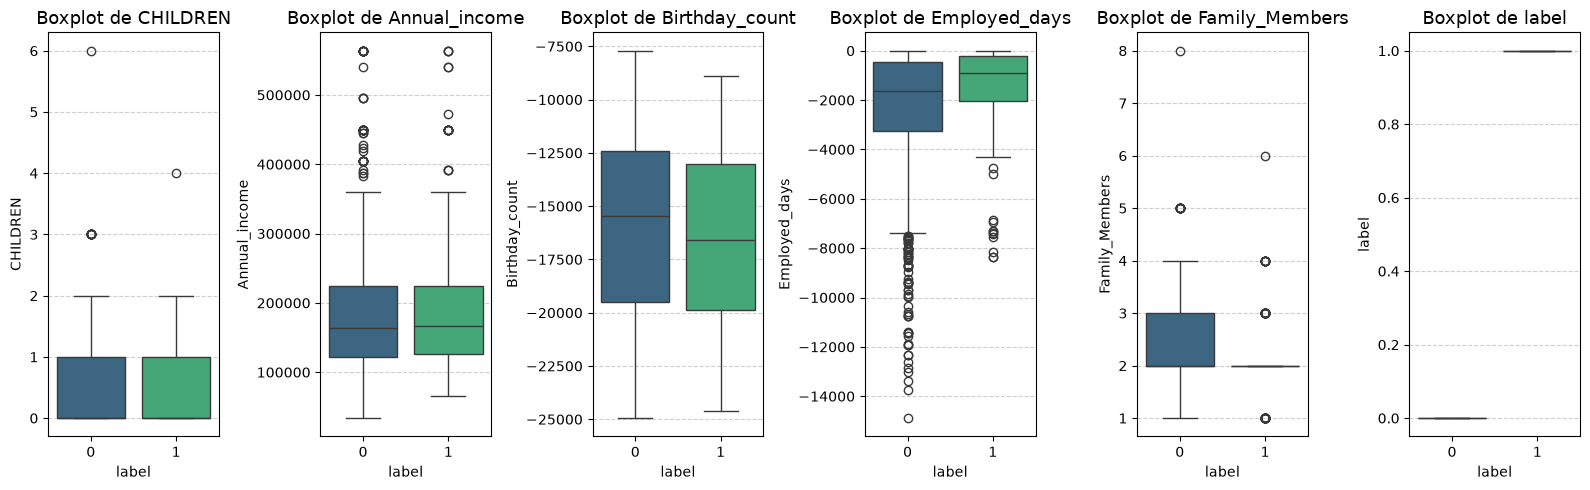

In [989]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración de la figura(creamos una cuadrícula de subplots)
fig, axes = plt.subplots(nrows = 1, ncols = 6, figsize = (16, 5))    
#Llama a los subplots indicando que tiene 2 filas y 5 columnas
#Llama a fig y axes de esta manera e itera sobre ellos, los subplots
axes = axes.flatten() #Hacemos que la matriz se transforme en unidimensional
#para no tener que hacer bucles con dos coordenadas

#Iteración para pintar cada subplot
for i, col in enumerate(numeric_cols):    #'enumerate' al pasarle una lista genera un contador numéritco
    sns.boxplot(                      #entonces 'i' valdría 0,1,2... y 'col' valdría 'edad,ingreso...'
        data = df,                    #con 'i' indicas a seaborn en que subplot estás y con 'col' extraes los datos del df
        x = 'label',
        y = col, 
        ax = axes[i],         #Que subplot estoy considerando
        hue = 'label',
        palette = 'viridis',
        orient = 'v',
        legend = False,       #Quita la leyenda repetitiva
    )
    axes[i].set_title(f"Boxplot de {col}", fontsize = 13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis = 'y', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

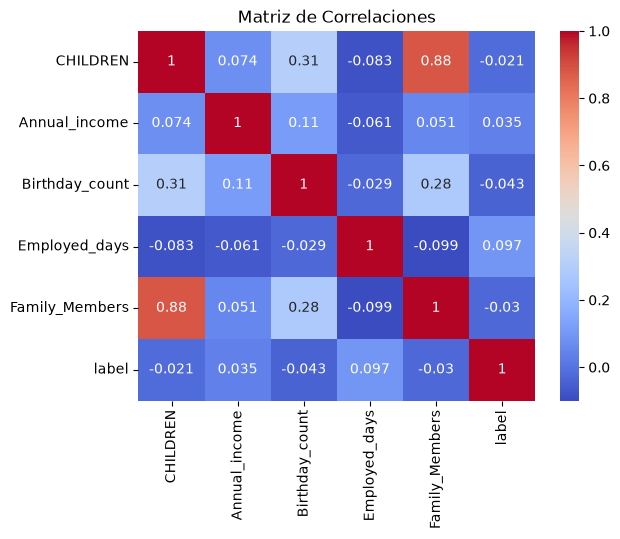

In [990]:
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title("Matriz de Correlaciones")
plt.show()

Viendo la alta correlación entre 'Family_Members' y 'CHILDREN' vamos a hacer un gráfico (scatterplot) donde representemos una frente a la otra para ver su linealidad.

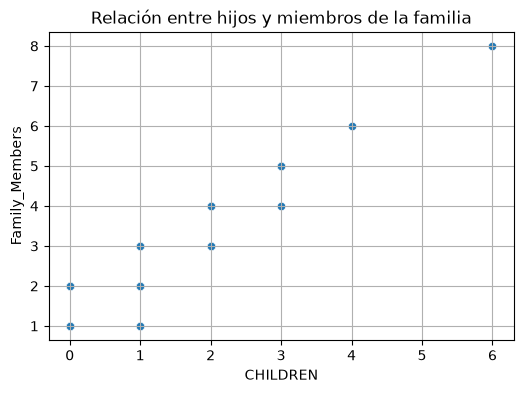

In [991]:
plt.figure(figsize = (6, 4))
sns.scatterplot(data = df, x = 'CHILDREN', y = 'Family_Members')
plt.title("Relación entre hijos y miembros de la familia")
plt.grid(True)
plt.show()

Vemos que ``CHILDREN`` y ``Family_Members`` están altamente correladas (como cabría esperar). 

Elimino la variable ``CHILDREN`` asumiendo que está contenida dentro de la otra, el resto no presentan problemas de colinealidad y redundancia

In [992]:
df.drop('CHILDREN', axis = 1, inplace = True)

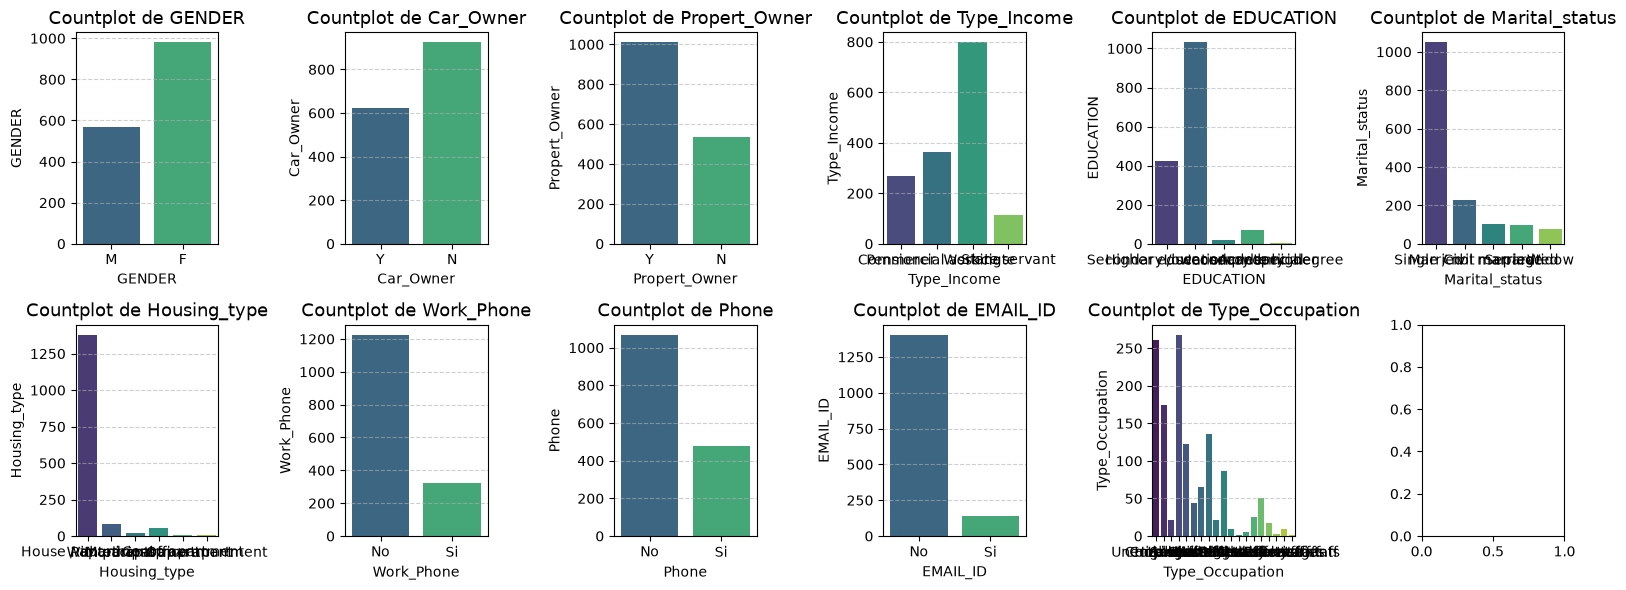

In [993]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración de la figura(creamos una cuadrícula de subplots)
fig, axes = plt.subplots(nrows = 2, ncols = 6, figsize = (16, 6))    
#Llama a los subplots indicando que tiene 2 filas y 5 columnas
#Llama a fig y axes de esta manera e itera sobre ellos, los subplots
axes = axes.flatten() #Hacemos que la matriz se transforme en unidimensional
#para no tener que hacer bucles con dos coordenadas

#Iteración para pintar cada subplot
for i, col in enumerate(categoric_cols):    #'enumerate' al pasarle una lista genera un contador numéritco
    sns.countplot(                      #entonces 'i' valdría 0,1,2... y 'col' valdría 'edad,ingreso...'
        data = df,                    #con 'i' indicas a seaborn en que subplot estás y con 'col' extraes los datos del df
        x = col, 
        ax = axes[i],         #Que subplot estoy considerando
        palette = 'viridis',
        legend = False,       #Quita la leyenda repetitiva
    )
    axes[i].set_title(f"Countplot de {col}", fontsize = 13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis = 'y', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

Observamos ciertas variables con demasiado número de categorías, lo que haremos será transformarlas y agruparlas.

In [994]:
df['Marital_status'].value_counts()

Marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: count, dtype: int64

In [995]:
df.groupby('Housing_type')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
Housing_type,,
House / apartment,0.105797,1380
With parents,0.062500,80
Municipal apartment,0.301887,53
Rented apartment,0.190476,21
Office apartment,0.222222,9
Co-op apartment,0.400000,5


Se observa que las categorías con menor número de observaciones tienen un impago en proporción más alto y parecen referirse todas a tipo alquiler/renta.

In [996]:
#Definimos nuestro límite de observaciones 
threshold = 60
#Calculamos cuántos clientes hay en cada categoría
frecuencias = df['Housing_type'].value_counts()
#Filtramos y nos quedamos solo con los NOMBRES de las vategorías 
#que no superan el threshold
categorias_raras = frecuencias[frecuencias < threshold].index
#Reemplazamos todas esas categorías minoritarias por 'Rent'
df['Housing_type'] = df['Housing_type'].replace(categorias_raras, 'Rent')
#Comprobamos resultados
df.groupby('Housing_type')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
Housing_type,,
House / apartment,0.105797,1380
Rent,0.272727,88
With parents,0.062500,80


In [997]:
df['Type_Occupation'].value_counts()

Type_Occupation
Laborers                 268
Unemployed               261
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

In [998]:
df.groupby('Type_Occupation', dropna = False)['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
Type_Occupation,,
Laborers,0.104478,268
Unemployed,0.134100,261
NaN,0.096916,227
Core staff,0.132184,174
Managers,0.102941,136
Sales staff,0.081967,122
Drivers,0.104651,86
High skill tech staff,0.107692,65
Medicine staff,0.060000,50


In [999]:
# Definimos el diccionario de agrupación por sector
agrupacion_laboral = {
    # Sector Servicios y Trabajo Manual (Suelen tener mayor rotación)
    'Laborers': 'Labor_Services',
    'Low-skill Laborers': 'Labor_Services',
    'Cleaning staff': 'Labor_Services',
    'Security staff': 'Labor_Services',
    'Waiters/barmen staff': 'Labor_Services',
    'Cooking staff': 'Labor_Services',
    'Private service staff': 'Labor_Services',
    'Drivers': 'Labor_Services',
    
    # Sector Corporativo y Administrativo (Mayor estabilidad)
    'Core staff': 'Corporate_Admin',
    'Managers': 'Corporate_Admin',
    'Accountants': 'Corporate_Admin',
    'HR staff': 'Corporate_Admin',
    'Secretaries': 'Corporate_Admin',
    'Realty agents': 'Corporate_Admin',
    
    # Sector Especializado / Técnico
    'High skill tech staff': 'Specialized_Tech',
    'IT staff': 'Specialized_Tech',
    'Medicine staff': 'Specialized_Tech',
}

# Aplicamos el mapeo creando una columna nueva (o sobreescribiendo)
df['Type_Occupation'] = df['Type_Occupation'].map(agrupacion_laboral).fillna('Unknown')

# Comprobamos cómo han quedado los tamaños de los nuevos grupos
print(df['Type_Occupation'].value_counts())

Type_Occupation
Unknown             610
Labor_Services      453
Corporate_Admin     368
Specialized_Tech    117
Name: count, dtype: int64


In [1000]:
df['EDUCATION'].value_counts()

EDUCATION
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: count, dtype: int64

In [1001]:
# Definimos el diccionario agrupando por nivel jerárquico
agrupacion_educacion = {
    # Nivel 1: Educación básica y secundaria (Juntamos los 21 de Lower con los 1031 de Secondary)
    'Lower secondary': 'Secondary',
    'Secondary / secondary special': 'Secondary',
    
    # Nivel 2: Educación superior incompleta (Mantenemos su grupo propio)
    'Incomplete higher': 'Incomplete_higher',
    
    # Nivel 3: Educación superior y posgrados (Juntamos los 2 de Academic Degree con Higher)
    'Higher education': 'Higher_education',
    'Academic degree': 'Higher_education'
}

# Aplicamos el mapeo creando una nueva columna o sobreescribiendo
df['EDUCATION'] = df['EDUCATION'].map(agrupacion_educacion)

# Comprobamos los nuevos tamaños
print(df['EDUCATION'].value_counts())

EDUCATION
Secondary            1052
Higher_education      428
Incomplete_higher      68
Name: count, dtype: int64


Comprobemos ahora como han quedado las variables finalmente y si tenemos alguna que otra que no diferencie bien entre buenos y malos pagadores para poder eliminarla y quitar ruido del modelo.

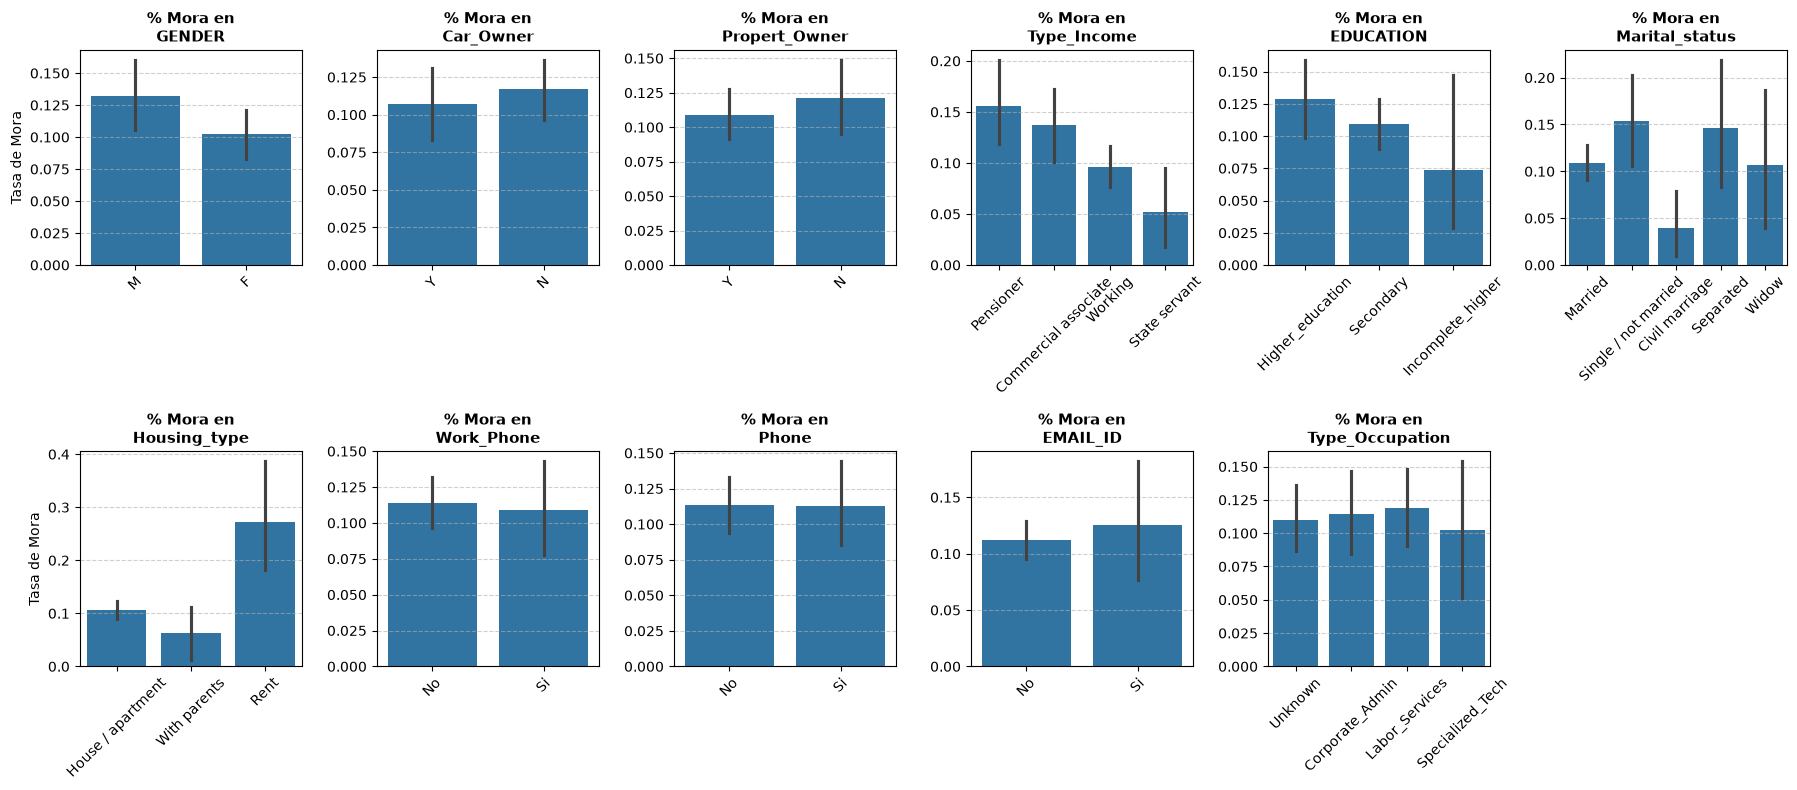

In [1002]:
# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(18, 8)) # Un poco más grande para que quepan los textos
axes = axes.flatten()

# Iteración para pintar cada gráfico de barras con el % (Tasa de Mora)
for i, col in enumerate(categoric_cols):
    # sns.barplot calcula la media por defecto (que en variables 0/1 es el %)
    sns.barplot(
        data=df, 
        x=col, 
        y='label',       # Al poner label en la Y, calcula la proporción de 1s
        ax=axes[i]
    )
    
    # Rotamos las etiquetas X porque en variables categóricas suelen solaparse
    axes[i].tick_params(axis='x', rotation=45) 
    
    # Títulos y etiquetas más precisos
    axes[i].set_title(f'% Mora en\n{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de Mora' if i % 6 == 0 else '') # Solo mostramos el nombre del eje Y en la primera columna
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Si tienes menos de 12 variables categóricas, esto borra los subplots vacíos que sobran
for j in range(len(categoric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

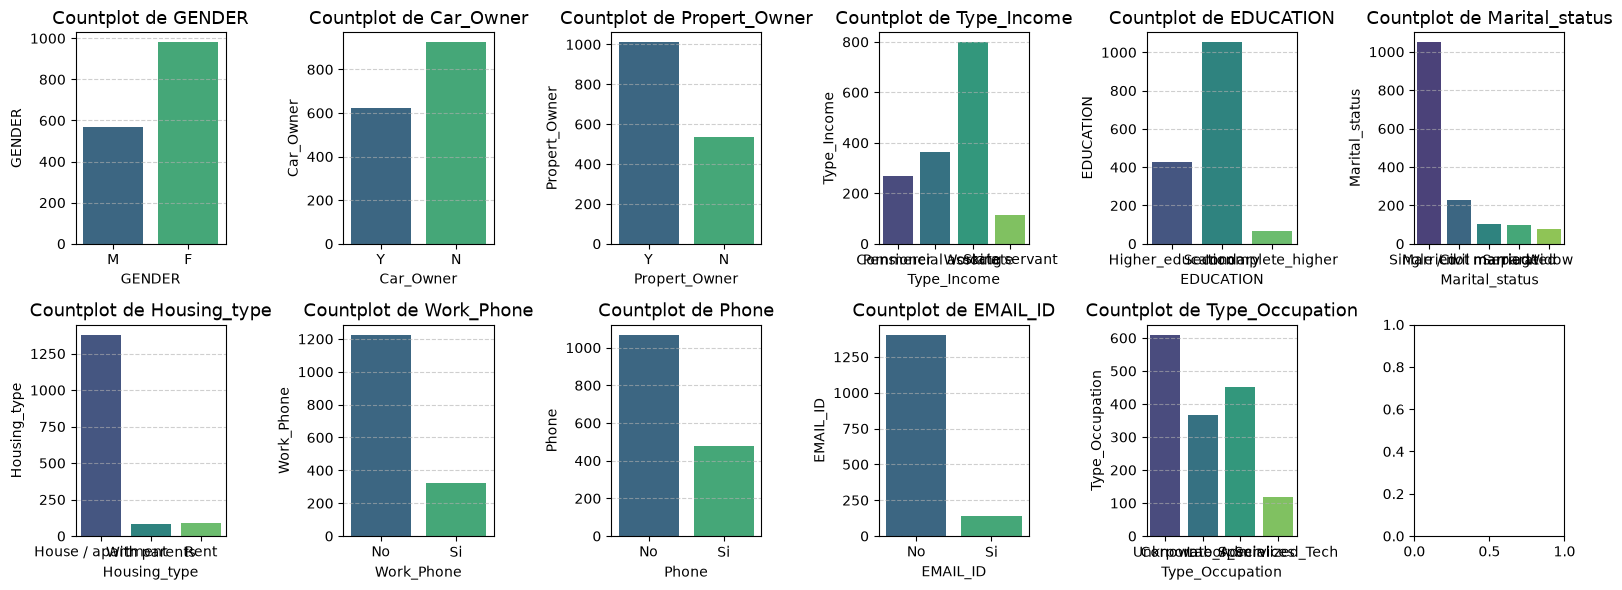

In [1003]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración de la figura(creamos una cuadrícula de subplots)
fig, axes = plt.subplots(nrows = 2, ncols = 6, figsize = (16, 6))    
#Llama a los subplots indicando que tiene 2 filas y 5 columnas
#Llama a fig y axes de esta manera e itera sobre ellos, los subplots
axes = axes.flatten() #Hacemos que la matriz se transforme en unidimensional
#para no tener que hacer bucles con dos coordenadas

#Iteración para pintar cada subplot
for i, col in enumerate(categoric_cols):    #'enumerate' al pasarle una lista genera un contador numéritco
    sns.countplot(                      #entonces 'i' valdría 0,1,2... y 'col' valdría 'edad,ingreso...'
        data = df,                    #con 'i' indicas a seaborn en que subplot estás y con 'col' extraes los datos del df
        x = col, 
        ax = axes[i],         #Que subplot estoy considerando
        palette = 'viridis',
        legend = False,       #Quita la leyenda repetitiva
    )
    axes[i].set_title(f"Countplot de {col}", fontsize = 13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis = 'y', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

Eliminemos las variables relacionadas con el teléfono pues vemos que tienen poca capacidad de separar entre buenos y malos pagadores. 

In [1004]:
df.drop(['Work_Phone', 'Phone'], axis = 1, inplace=True)

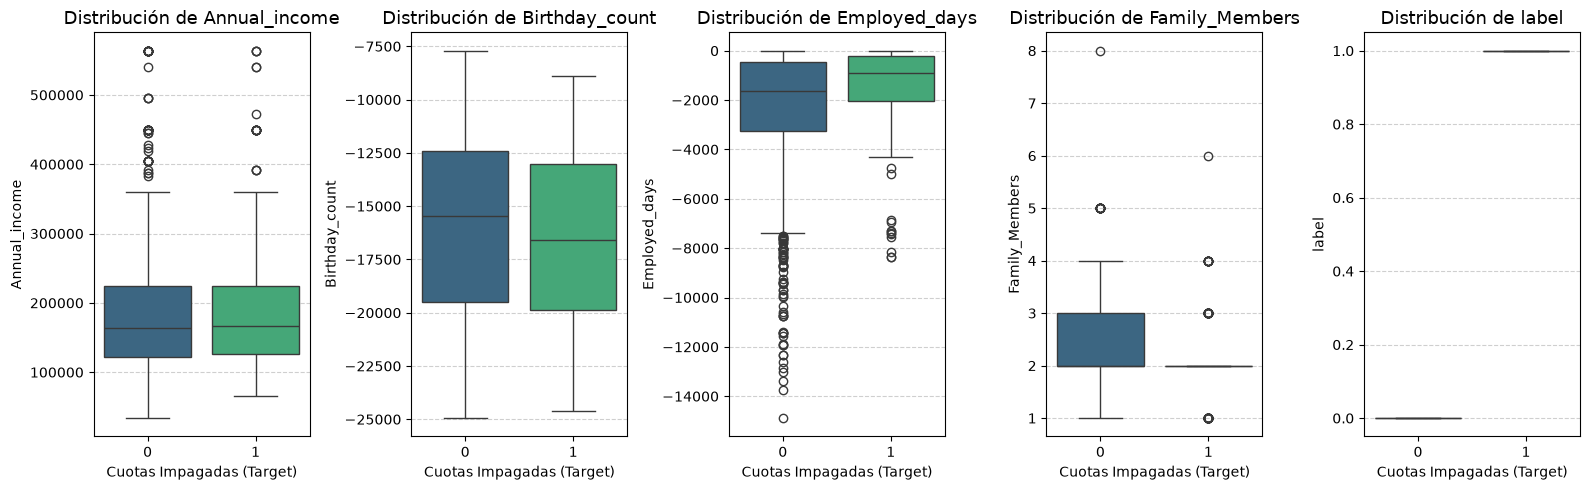

In [1005]:
# Extraer de nuevo variables numericas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(16, 5))
axes = axes.flatten()

# Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        x='label', 
        y=col, 
        ax=axes[i], 
        palette='viridis',
        orient='v',
        hue='label',       # Añade color por categoría
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('Cuotas Impagadas (Target)')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Modelización

In [1006]:
y = df['label']
X = df.drop(columns = ['label'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [1007]:
# Comprobamos cómo han quedado los tamaños
print(f"Total de clientes originales: {len(df)}")
print(f"Clientes para Entrenamiento (Train): {len(X_train)}")
print(f"Clientes para Evaluación (Test): {len(X_test)}")

Total de clientes originales: 1548
Clientes para Entrenamiento (Train): 1083
Clientes para Evaluación (Test): 465


In [1008]:
cat_cols = X_train.select_dtypes(include = ['object']).columns.tolist()

X_train = pd.get_dummies(X_train, columns = cat_cols, drop_first = True)
X_test = pd.get_dummies(X_test, columns = cat_cols, drop_first = True)

# Alineamos las columnas del Train/Test
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)

In [1009]:
num_cols = X_train.select_dtypes(include = [np.number]).columns.tolist()

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

In [1010]:
X_train.head()

,Annual_income,Birthday_count,Employed_days,Family_Members,GENDER_M,Car_Owner_Y,Propert_Owner_Y,Type_Income_Pensioner,Type_Income_State servant,Type_Income_Working,...,Marital_status_Married,Marital_status_Separated,Marital_status_Single / not married,Marital_status_Widow,Housing_type_Rent,Housing_type_With parents,EMAIL_ID_Si,Type_Occupation_Labor_Services,Type_Occupation_Specialized_Tech,Type_Occupation_Unknown
730,-0.573359,0.309435,0.379775,-1.268853,False,False,True,False,False,True,...,False,True,False,False,False,False,False,False,False,True
100,-1.078943,0.248809,-1.887380,0.908909,True,False,False,False,True,False,...,True,False,False,False,True,False,False,False,False,False
619,-1.078943,1.393780,0.549271,0.908909,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
838,-1.262791,1.050790,-0.234084,-0.179972,True,False,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False
1419,-0.803170,-1.330090,0.916851,-1.268853,False,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,True


In [1016]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score

# Definición de Modelos (Añadimos class_weight='balanced' como vimos antes por los morosos)
modelos = {
    "Logística": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Árbol": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "Random Forest Base": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# Entrenamiento y Evaluación
resultados = []

for nombre, mod in modelos.items():
    # 1. Entrenar
    mod.fit(X_train, y_train)
    
    # 2. Predecir (0 o 1) para Recall y F1
    preds = mod.predict(X_test)
    
    # 3. Predecir probabilidades (porcentaje) para el AUC
    probs = mod.predict_proba(X_test)[:, 1]
    
    # 4. Calcular métricas
    auc = roc_auc_score(y_test, probs)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    # 5. Guardar resultados
    resultados.append({
        "Modelo": nombre, 
        "ROC-AUC": auc,
        "Recall": recall,
        "F1-Score": f1 
    })

# Convertimos a DataFrame, multiplicamos por 100 y ordenamos por el Recall (Caza-Morosos)
df_benchmark = pd.DataFrame(resultados).set_index("Modelo")
df_benchmark = (df_benchmark * 100).round(2)
df_benchmark.sort_values(by="Recall", ascending=False)

,ROC-AUC,Recall,F1-Score
Modelo,,,
Logística,66.56,67.44,24.37
Árbol,66.68,55.81,26.82
Random Forest Base,82.01,53.49,59.74


Vamos a extraer las predicciones de cada modelo para el análisis comparativo final.

In [1017]:
# Creamos un diccionario vacío para guardar las predicciones de cada modelo
diccionario_predicciones = {}

for nombre, mod in modelos.items():
    mod.fit(X_train, y_train)
    
    # Guardamos las predicciones (0 y 1) asociadas al nombre del modelo
    diccionario_predicciones[nombre] = mod.predict(X_test)

# Ahora puedes extraerlas así para usarlas donde quieras:
predicciones_lr = diccionario_predicciones["Logística"]
predicciones_tree = diccionario_predicciones["Árbol"]
predicciones_rf = diccionario_predicciones["Random Forest Base"]

Vamos a hacer ahora el 'grid search' para entrenar el modelo Random Forest e intentar obtener mejores predicciones

In [1018]:
from sklearn.model_selection import GridSearchCV

#Definimos el grid de parámetros a explorar
#Mantenemos las opciones acotadas para que no tarde 3 horas en entrenar
param_grid = {
    'n_estimators': [50, 100, 200], #Cuántos árboles plantamos en el bosque
    'max_depth': [5, 10, None], #Profundidad máxima (para que no se aprendan cada cliente de memoria)
    'min_samples_leaf': [1, 5, 10] #Mínimo de clientes en la decisión final (evita ramas inútiles)
}

#Instanciamos el modelo base
#Mantenemos 'class_weight=balanced' para que siga dándole peso a los morosos
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

#Configuramos el buscador
grid_search = GridSearchCV(
    estimator = rf_base,
    param_grid = param_grid,
    scoring = 'roc_auc', #Métrica de negocio: Queremos el modelo que separe mejor a buenos de malos 
    cv = 5, #Validación Cruzada (Cross-Validation) de 5 pliegues
    verbose = 2 #Nos irá imprimiendo por pantalla por dónde va
)

#Lanzamos el entrenamiento (Aviso: Esto probará 3x3x3 = 27 combinaciones x 5 pliegues (CV) = 135 entrenamientos)
grid_search.fit(X_train, y_train)

#Guardamos el mejor modelo
mejor_rf = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.0s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=5, min_samples_leaf=1, n_e

In [1019]:
print(f"Mejores Hiperparámetros encontrados: \n{grid_search.best_params_}")

Mejores Hiperparámetros encontrados: 
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}


Ahora vamos a comprobar los resultados de nuestro modelo de Random Forest y los demás modelos que hemos entrenado con detalle

In [1020]:
predicciones_mejor_rf = mejor_rf.predict(X_test)
probabilidades_mejor_rf = mejor_rf.predict_proba(X_test)[:, 1]

In [1021]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, f1_score

# Recopilamos las métricas de todos los modelos en un diccionario
# (Asumimos que ya tenías guardadas las predicciones de los modelos base)
resultados = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'RF Base', 'RF Optimizado'],
    'Accuracy (Aciertos)': [
        accuracy_score(y_test, predicciones_lr),
        accuracy_score(y_test, predicciones_tree),
        accuracy_score(y_test, predicciones_rf),
        accuracy_score(y_test, predicciones_mejor_rf)
    ],
    'Recall (Caza-Morosos)': [
        recall_score(y_test, predicciones_lr),
        recall_score(y_test, predicciones_tree),
        recall_score(y_test, predicciones_rf),
        recall_score(y_test, predicciones_mejor_rf)
    ],
    'ROC-AUC (Poder de Ranking)': [
        roc_auc_score(y_test, predicciones_lr),
        roc_auc_score(y_test, predicciones_tree),
        roc_auc_score(y_test, predicciones_rf),
        roc_auc_score(y_test, probabilidades_mejor_rf)
    ],
    'F1-Score (Equilibrio)': [
        f1_score(y_test, predicciones_lr),
        f1_score(y_test, predicciones_tree),
        f1_score(y_test, predicciones_rf),
        f1_score(y_test, predicciones_mejor_rf)
    ]
}

# Creamos el DataFrame, lo multiplicamos por 100 para ver % y lo ordenamos por Recall
df_benchmark = pd.DataFrame(resultados)
df_benchmark.set_index('Modelo', inplace=True)
df_benchmark = (df_benchmark * 100).round(2)

# Mostramos la tabla ordenada de mejor a peor cazador de morosos
df_benchmark.sort_values(by='Recall (Caza-Morosos)', ascending=False)

,Accuracy (Aciertos),Recall (Caza-Morosos),ROC-AUC (Poder de Ranking),F1-Score (Equilibrio)
Modelo,,,,
Regresión Logística,61.29,67.44,64.05,24.37
Árbol de Decisión,71.83,55.81,64.64,26.82
RF Base,93.33,53.49,75.44,59.74
RF Optimizado,93.33,53.49,82.01,59.74


Vemos que el Random Forest es claramente mejor a los demás modelos en térmios de AUC, accuracy y F1, pero sin embargo en términos del Recall (los impagos que detectamos) el mejor modelo es la Regresión Logística. Por tanto, dependiendo de los objetivos del banco eligríamos un modelo u otro:

- Regresión logística: Si el modelo debe ser interpretable o el banco es conservador y su objetivo principal es detectar a los morosos más que tener una alta accuracy. 

- Random Forest: Si el objetivo es maximizar la accuracy independientemente del % de acierto en mororos. 

Esto puede ser un poco antiuitivo, pero en problemas desbalanceados como este (solo el 11% son morosos) ocurren muchas veces estas cosas. De ahí que sea tan importante entender todas las métricas para seleccionar el modelo más adecuado.

Espero que hayas podido llegar a un modelo tan bueno como este e incluso mejor. Podrías haber hecho una limpieza de variables distintas, construir más variables, utilizar más modelos o más hiperparámetros... Las posibilidades son infinitas ahora que dominas Python y el ML, así que espero tu mensaje diciendo que has obtenido un error más bajo al mío ;)

Y por supuesto, enhorabuena, después de llegar hasta aquí ya has aprendido todo lo que necesitas para resolver un problema de clasifiación como un Data Scientist pro.
